In [1]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

Phase 1: Loading Pavia University dataset...
Image shape: (610, 340, 103) | GT shape: (610, 340)


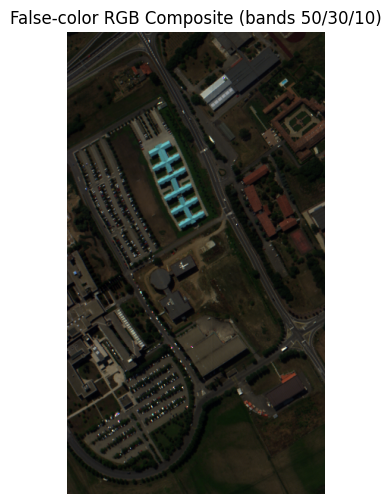

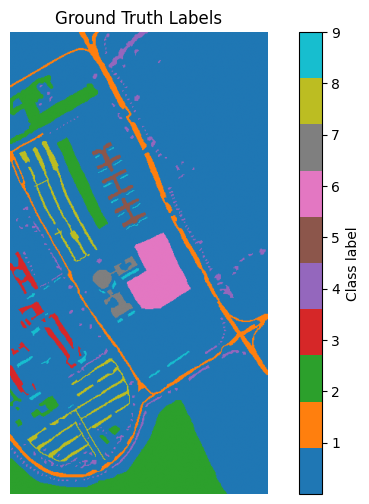

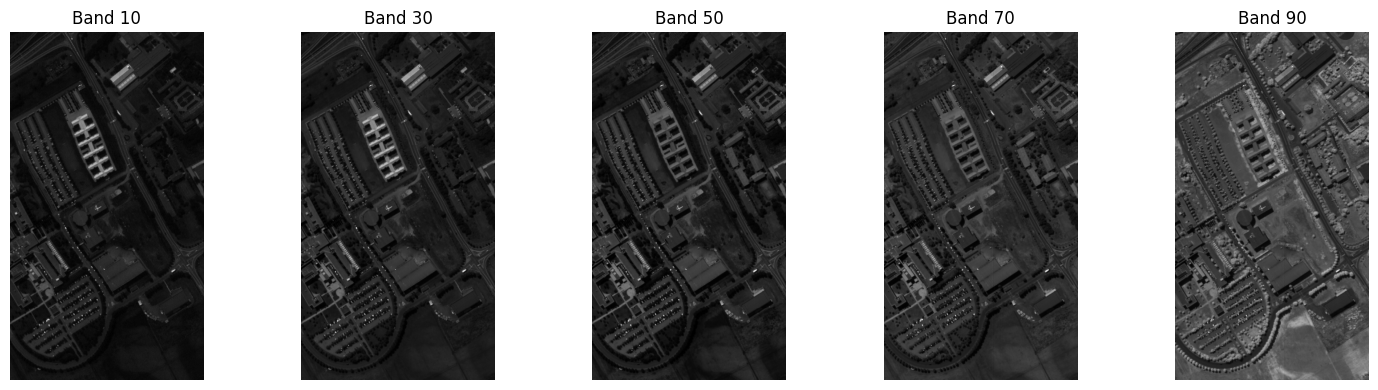

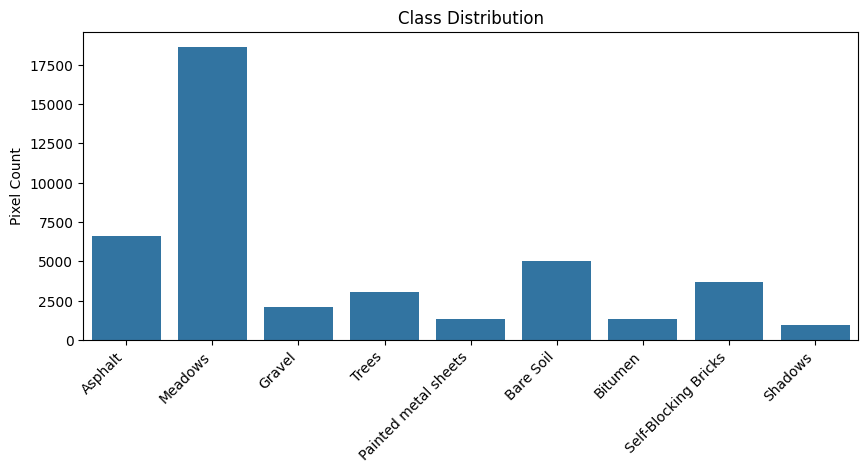

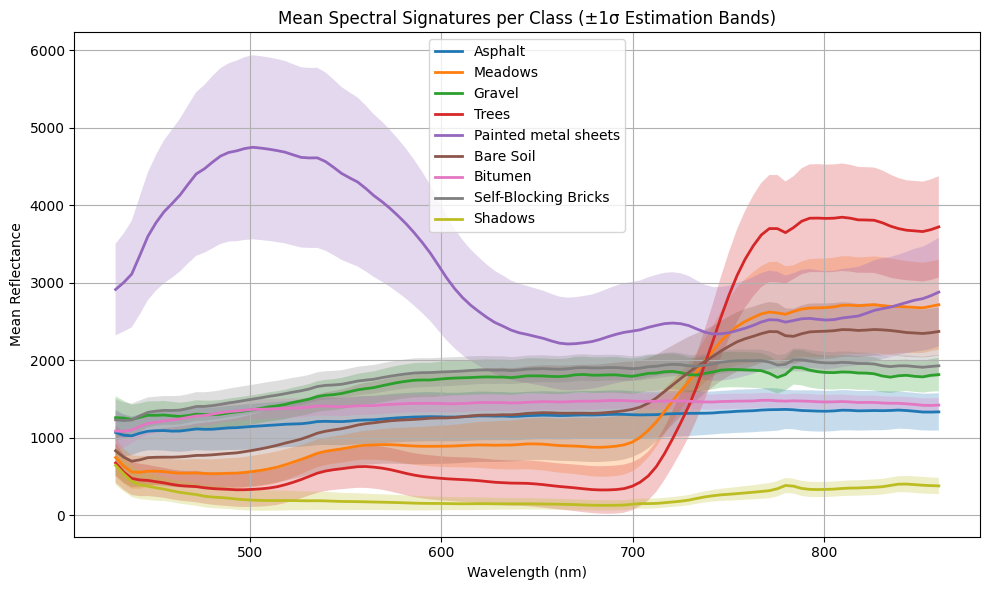

In [2]:
# ====================== PHASE 1: DATA LOADING & EXPLORATION ======================
print("Phase 1: Loading Pavia University dataset...")
data = sio.loadmat('PaviaU.mat')
paviaU = data['paviaU']          # shape: (610, 340, 103)
gt_data = sio.loadmat('paviaU_gt.mat')
gt = gt_data.get('paviaU_gt', None)
if gt is None:  # fallback for variable name differences
    gt = list(gt_data.values())[0]  # first numeric matrix
print(f"Image shape: {paviaU.shape} | GT shape: {gt.shape}")

# False-color RGB composite (bands 50/30/10 - same as your MATLAB)
r, g, b = 50, 30, 10
rgb = np.stack([paviaU[:, :, r], paviaU[:, :, g], paviaU[:, :, b]], axis=-1)
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())  # rescale [0,1]
plt.figure(figsize=(8, 6))
plt.imshow(rgb)
plt.title('False-color RGB Composite (bands 50/30/10)')
plt.axis('off')
plt.show()

# Ground Truth map
plt.figure(figsize=(8, 6))
plt.imshow(gt, cmap='tab10')
plt.title('Ground Truth Labels')
plt.colorbar(ticks=range(1, 10), label='Class label')
plt.axis('off')
plt.show()

# Grayscale band examples
bands_to_plot = [10, 30, 50, 70, 90]
fig, axes = plt.subplots(1, len(bands_to_plot), figsize=(15, 4))
for ax, band in zip(axes, bands_to_plot):
    ax.imshow(paviaU[:, :, band-1], cmap='gray')  # 0-based indexing
    ax.set_title(f'Band {band}')
    ax.axis('off')
plt.tight_layout()
plt.show()

# Class distribution
class_labels = ['Asphalt', 'Meadows', 'Gravel', 'Trees', 'Painted metal sheets',
                'Bare Soil', 'Bitumen', 'Self-Blocking Bricks', 'Shadows']
class_counts = np.bincount(gt.ravel())[1:]  # skip class 0 (background)
plt.figure(figsize=(10, 4))
sns.barplot(x=class_labels, y=class_counts)
plt.xticks(rotation=45, ha='right')
plt.title('Class Distribution')
plt.ylabel('Pixel Count')
plt.show()

# === UPDATED MEAN SPECTRAL SIGNATURES WITH ESTIMATIONS (Chhaya-style) ===
wavelengths = 430 + np.arange(103) * (860 - 430) / 102
mean_spectra = np.zeros((9, 103))
std_spectra  = np.zeros((9, 103))   # NEW: standard deviation per class per band

for c in range(1, 10):
    mask = (gt == c)
    pixels = paviaU[mask]                    # shape (N_pixels, 103)
    mean_spectra[c-1] = np.mean(pixels, axis=0)
    std_spectra[c-1]  = np.std(pixels, axis=0)   # per-band std dev

plt.figure(figsize=(10, 6))
class_labels = ['Asphalt', 'Meadows', 'Gravel', 'Trees', 'Painted metal sheets',
                'Bare Soil', 'Bitumen', 'Self-Blocking Bricks', 'Shadows']

for i, label in enumerate(class_labels):
    plt.plot(wavelengths, mean_spectra[i], label=label, linewidth=2)
    # Shaded estimation band (±1 std dev) - this is what Chhaya used
    plt.fill_between(wavelengths,
                     mean_spectra[i] - std_spectra[i],
                     mean_spectra[i] + std_spectra[i],
                     alpha=0.25)   # semi-transparent fill

plt.xlabel('Wavelength (nm)')
plt.ylabel('Mean Reflectance')
plt.title('Mean Spectral Signatures per Class (±1σ Estimation Bands)')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

In [3]:
# ====================== PHASE 2: PREPROCESSING & STRATIFIED SPLIT ======================
print("\nPhase 2: Preprocessing and splitting...")
labeled_mask = gt > 0
X = paviaU[labeled_mask].reshape(-1, 103)   # (N_labeled, 103)
y = gt[labeled_mask].ravel()

# Min-max normalization [0,1] - identical to MATLAB normalize(..., 'range')
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X)

# Stratified 70/15/15 split (exact equivalent to your cvpartition logic)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_norm, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.15/0.85, stratify=y_train_val, random_state=42)

print(f"Train: {X_train.shape[0]} ({X_train.shape[0]/len(y):.2%}) | "
      f"Val: {X_val.shape[0]} ({X_val.shape[0]/len(y):.2%}) | "
      f"Test: {X_test.shape[0]} ({X_test.shape[0]/len(y):.2%})")

# Optional PCA (25 components as in your script - combats Hughes phenomenon)
pca = PCA(n_components=25, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_val_pca   = pca.transform(X_val)
X_test_pca  = pca.transform(X_test)
print(f"PCA retained variance: {np.sum(pca.explained_variance_ratio_):.2%}")


Phase 2: Preprocessing and splitting...
Train: 29942 (70.00%) | Val: 6417 (15.00%) | Test: 6417 (15.00%)
PCA retained variance: 99.96%


In [4]:
# ====================== PHASE 3: TRADITIONAL ML MODELS (FIXED) ======================
print("\nPhase 3: Training traditional ML models...")

# Force integer labels (critical after .mat load)
labeled_mask = gt > 0
X = paviaU[labeled_mask].reshape(-1, 103)
y = gt[labeled_mask].ravel().astype(np.int32)   # ← THIS LINE FIXES THE ERROR

print("Unique labels in y (should be only 1-9):", np.unique(y))  # diagnostic

# Re-split with the cleaned y
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_norm, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.15/0.85, stratify=y_train_val, random_state=42)

# Inverse-frequency weights (still works for SVM & RF)
from collections import Counter
counts = Counter(y_train)
class_weights = {cls: len(y_train) / (len(class_labels) * count) for cls, count in counts.items()}

# 1. KNN (unchanged)
knn = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
knn.fit(X_train_pca, y_train)
y_pred_knn = knn.predict(X_test_pca)
print(f"KNN Test OA: {accuracy_score(y_test, y_pred_knn):.4f}")

# 2. SVM-RBF (uses the fixed class_weights)
svm = SVC(kernel='rbf', C=10, gamma='scale', class_weight=class_weights, random_state=42)
svm.fit(X_train_pca, y_train)
y_pred_svm = svm.predict(X_test_pca)
print(f"SVM-RBF Test OA: {accuracy_score(y_test, y_pred_svm):.4f}")

# 3. Random Forest (uses the fixed class_weights)
rf = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_leaf=1,
                            class_weight=class_weights, random_state=42, n_jobs=-1)
rf.fit(X_train_pca, y_train)
y_pred_rf = rf.predict(X_test_pca)
print(f"Random Forest Test OA: {accuracy_score(y_test, y_pred_rf):.4f}")

# 4. Gradient Boosting – FIXED with 'balanced' (equivalent & foolproof)
from sklearn.ensemble import HistGradientBoostingClassifier
gb = HistGradientBoostingClassifier(
    max_iter=300,
    max_depth=8,
    class_weight='balanced',      # ← simplest & correct fix
    random_state=42
)
gb.fit(X_train_pca, y_train)
y_pred_gb = gb.predict(X_test_pca)
print(f"Gradient Boosting Test OA: {accuracy_score(y_test, y_pred_gb):.4f}")


Phase 3: Training traditional ML models...
Unique labels in y (should be only 1-9): [1 2 3 4 5 6 7 8 9]
KNN Test OA: 0.8904
SVM-RBF Test OA: 0.9221
Random Forest Test OA: 0.9168
Gradient Boosting Test OA: 0.9437


Generating full-scene classification maps...


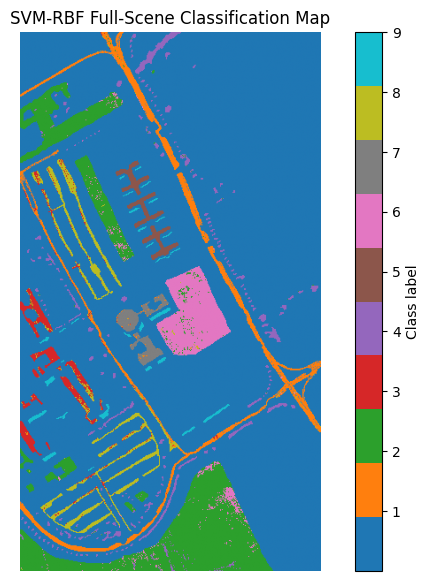

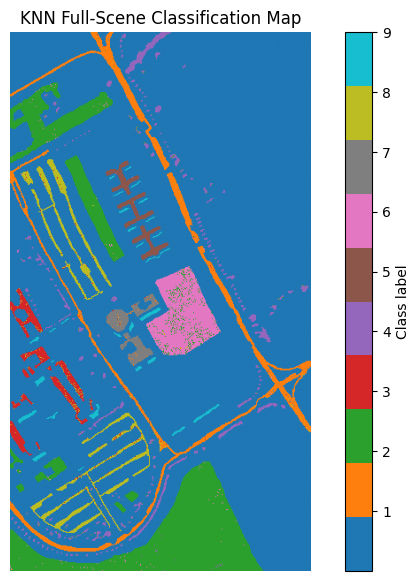

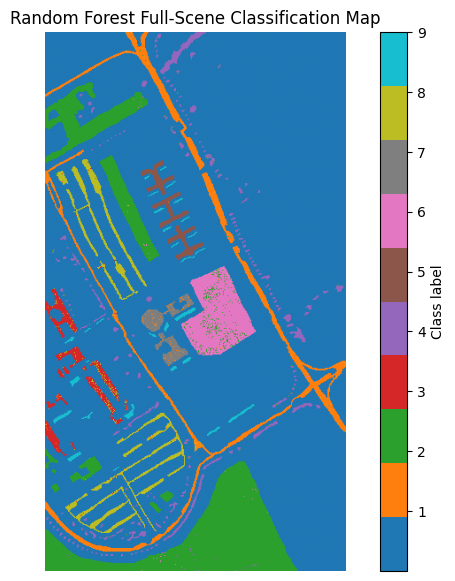

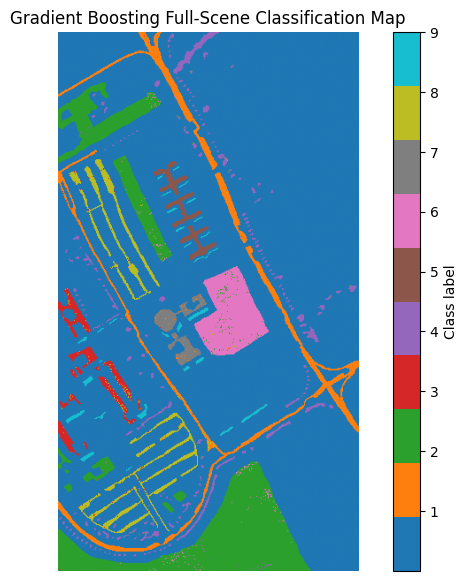

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [2, 2, 2, ..., 0, 0, 0],
       [2, 2, 3, ..., 0, 0, 0],
       [2, 2, 2, ..., 0, 0, 0]], shape=(610, 340))

In [5]:
# ====================== FULL-SCENE CLASSIFICATION MAPS (Clean & Reusable) ======================
print("Generating full-scene classification maps...")

# Helper function — call it once per model
def generate_classification_map(model, model_name):
    # Re-create the labeled mask and full-scene features (safe even if cell order changes)
    labeled_mask = gt > 0
    X_full = paviaU[labeled_mask].reshape(-1, 103)      # only labeled pixels
    X_full_norm = scaler.transform(X_full)
    X_full_pca  = pca.transform(X_full_norm)
    
    y_map = model.predict(X_full_pca)
    
    # Build the classification map image
    class_map = np.zeros(gt.shape, dtype=int)
    class_map[labeled_mask] = y_map
    
    # Plot
    plt.figure(figsize=(9, 7))
    plt.imshow(class_map, cmap='tab10')
    plt.title(f'{model_name} Full-Scene Classification Map')
    plt.colorbar(ticks=range(1, 10), label='Class label')
    plt.axis('off')
    plt.show()
    
    return class_map   # optional: you can save this for the poster if needed

# Generate all four required maps (just call the function)
generate_classification_map(svm, 'SVM-RBF')
generate_classification_map(knn, 'KNN')
generate_classification_map(rf, 'Random Forest')
generate_classification_map(gb, 'Gradient Boosting')

=== Robust Evaluation & Ablation Studies ===
            Model OA (%) AA (%)  Kappa Time (s)
              KNN  89.04  87.51 0.8524    0.151
          SVM-RBF  92.21  90.82 0.8979    4.989
    Random Forest  91.68  89.71 0.8879    0.050
Gradient Boosting  94.37  92.84 0.9255    0.070

PCA Ablation Study (OA vs. number of components)...


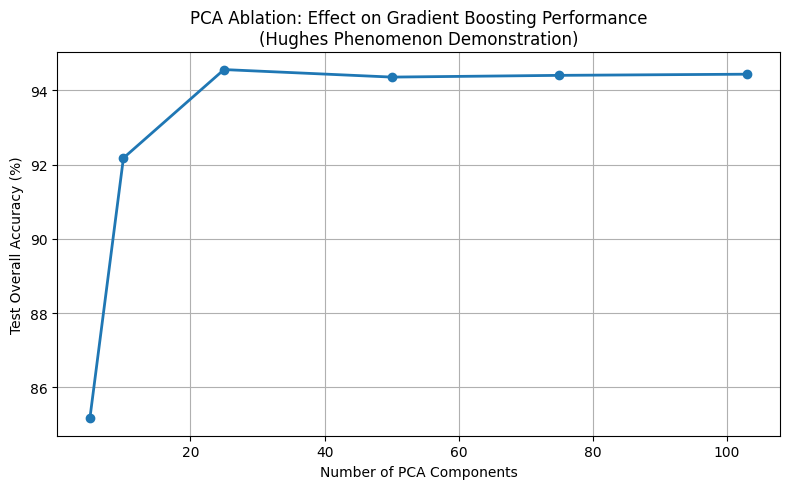

PCA Ablation complete — figure saved as pca_ablation.png
Generating feature importance plots...


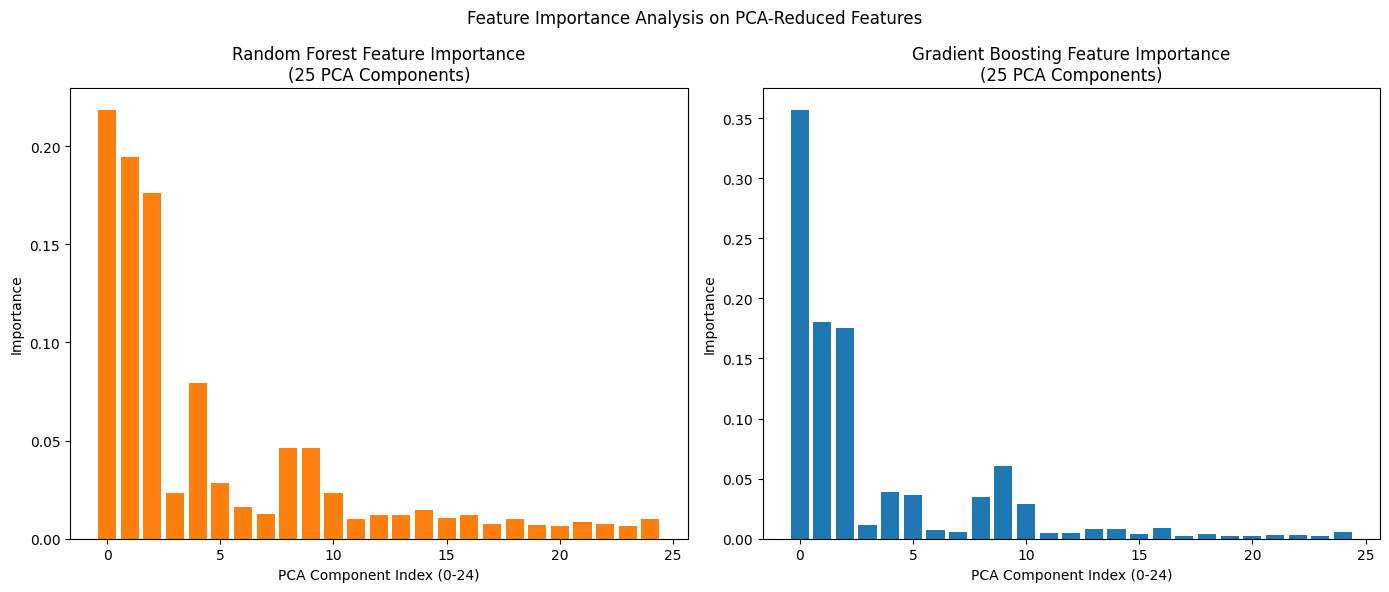

Feature importance plots saved as feature_importance.png


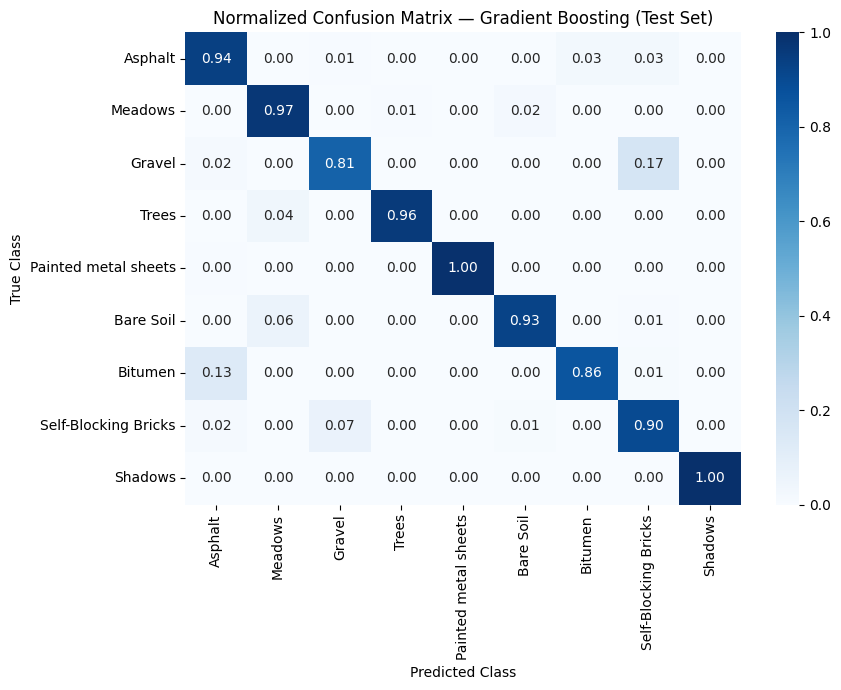

5-fold CV OA (GB): 0.9445 ± 0.0019


In [7]:
# ====================== PHASE 3.5: ROBUST EVALUATION & GIST-LEVEL VISUALS ======================
from sklearn.metrics import classification_report, cohen_kappa_score, confusion_matrix
import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

print("=== Robust Evaluation & Ablation Studies ===")

models = {'KNN': knn, 'SVM-RBF': svm, 'Random Forest': rf, 'Gradient Boosting': gb}
results = []

for name, model in models.items():
    start = time.time()
    y_pred = model.predict(X_test_pca)
    duration = time.time() - start
    
    oa = accuracy_score(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    aa = report['macro avg']['f1-score']   # Average Accuracy via macro F1 (standard in HSI literature)
    
    results.append({
        'Model': name,
        'OA (%)': f"{oa*100:.2f}",
        'AA (%)': f"{aa*100:.2f}",
        'Kappa': f"{kappa:.4f}",
        'Time (s)': f"{duration:.3f}"
    })

# Summary Table (copy straight into poster)
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

# Save high-res table for poster
df_results.to_latex('results_table.tex', index=False)   # or .csv

# ====================== PCA ABLATION (Hughes Phenomenon) ======================
print("\nPCA Ablation Study (OA vs. number of components)...")
n_comps = [5, 10, 25, 50, 75, 103]
oa_scores = []
for n in n_comps:
    pca_temp = PCA(n_components=n, random_state=42)
    X_train_temp = pca_temp.fit_transform(X_train)
    X_test_temp  = pca_temp.transform(X_test)
    
    # FIXED: Use HistGradientBoostingClassifier (consistent with your main GB model)
    gb_temp = HistGradientBoostingClassifier(
        max_iter=100,          # correct parameter for HistGB
        random_state=42
    )
    gb_temp.fit(X_train_temp, y_train)
    oa_scores.append(accuracy_score(y_test, gb_temp.predict(X_test_temp)))

plt.figure(figsize=(8, 5))
plt.plot(n_comps, [s*100 for s in oa_scores], marker='o', linewidth=2, color='tab:blue')
plt.xlabel('Number of PCA Components')
plt.ylabel('Test Overall Accuracy (%)')
plt.title('PCA Ablation: Effect on Gradient Boosting Performance\n(Hughes Phenomenon Demonstration)')
plt.grid(True)
plt.tight_layout()
plt.savefig('pca_ablation.png', dpi=300, bbox_inches='tight')
plt.show()

print("PCA Ablation complete — figure saved as pca_ablation.png")

# ====================== FEATURE IMPORTANCE (RF & GB) ======================
print("Generating feature importance plots...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest (unchanged - works on PCA features)
importances_rf = rf.feature_importances_
axes[0].bar(range(len(importances_rf)), importances_rf, color='tab:orange')
axes[0].set_title('Random Forest Feature Importance\n(25 PCA Components)')
axes[0].set_xlabel('PCA Component Index (0-24)')
axes[0].set_ylabel('Importance')

# Gradient Boosting — use classic version ONLY for visualization
from sklearn.ensemble import GradientBoostingClassifier
gb_classic = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)
gb_classic.fit(X_train_pca, y_train)   # quick retrain on same data

importances_gb = gb_classic.feature_importances_
axes[1].bar(range(len(importances_gb)), importances_gb, color='tab:blue')
axes[1].set_title('Gradient Boosting Feature Importance\n(25 PCA Components)')
axes[1].set_xlabel('PCA Component Index (0-24)')
axes[1].set_ylabel('Importance')

plt.suptitle('Feature Importance Analysis on PCA-Reduced Features')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Feature importance plots saved as feature_importance.png")

# ====================== NORMALIZED CONFUSION MATRIX (Best Model: GB) ======================
y_pred_gb = gb.predict(X_test_pca)
cm = confusion_matrix(y_test, y_pred_gb, normalize='true')
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Normalized Confusion Matrix — Gradient Boosting (Test Set)')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.savefig('cm_normalized_gb.png', dpi=300, bbox_inches='tight')
plt.show()

# Optional 5-fold CV for extra robustness (takes ~30s)
cv_scores = cross_val_score(gb, X_train_pca, y_train, cv=5, scoring='accuracy')
print(f"5-fold CV OA (GB): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")